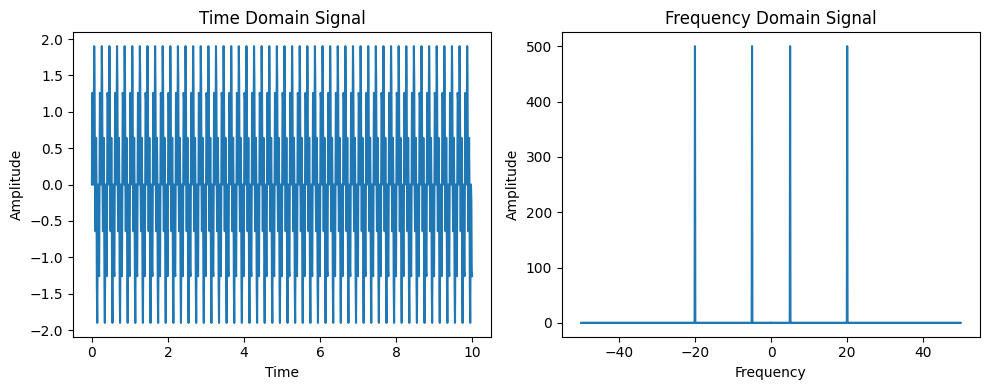

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# Generate a sample signal (sine wave)
# Define the time domain
n_samples = 1000  # Number of samples
timestep = 0.01  # Time step between samples
time = np.arange(0, n_samples * timestep, timestep)

# Create a signal composed of two sine waves with different frequencies
frequency1 = 5  # Frequency of the first sine wave
frequency2 = 20  # Frequency of the second sine wave
signal = np.sin(2 * np.pi * frequency1 * time) + np.sin(2 * np.pi * frequency2 * time)

# Perform Fourier transformation
fourier_transformed = fft(signal)
frequencies = fftfreq(n_samples, timestep)

# Plot the time-domain signal
plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.title('Time Domain Signal')
plt.plot(time, signal)
plt.xlabel('Time')
plt.ylabel('Amplitude')

# Plot the frequency-domain representation
plt.subplot(122)
plt.title('Frequency Domain Signal')
plt.plot(frequencies, np.abs(fourier_transformed))
plt.xlabel('Frequency')
plt.ylabel('Amplitude')

plt.tight_layout()
plt.show()


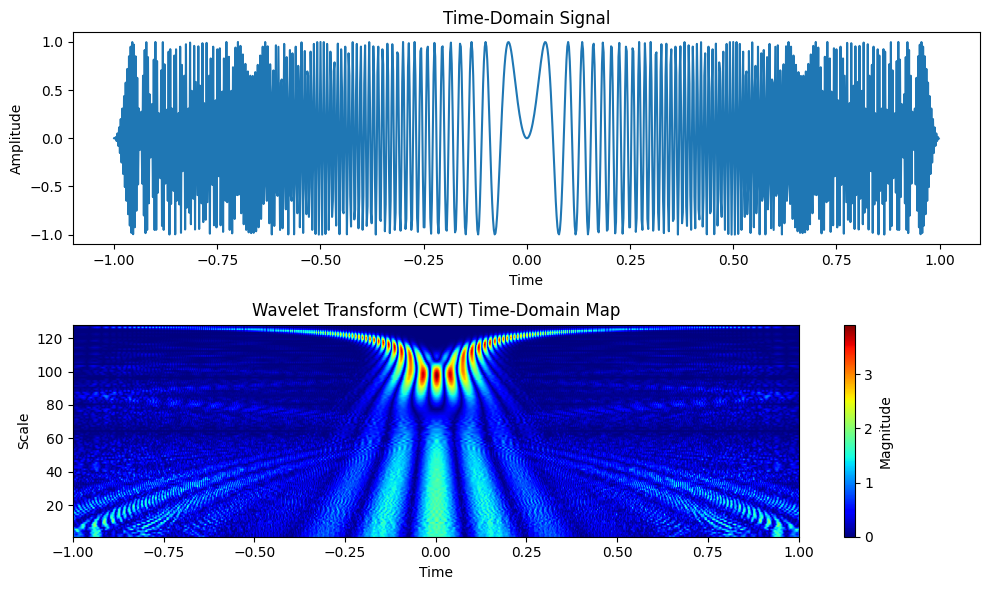

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pywt

# Generate a signal (example: chirp signal)
t = np.linspace(-1, 1, 1000, endpoint=False)
signal = np.sin(250 * np.pi * t**2)

# Continuous Wavelet Transform (CWT)
scales = np.arange(1, 128)
wavelet = 'morl'  # Choose a wavelet (e.g., Morlet wavelet)
coefs, freqs = pywt.cwt(signal, scales, wavelet)

# Plotting
plt.figure(figsize=(10, 6))

plt.subplot(211)
plt.plot(t, signal)
plt.title('Time-Domain Signal')
plt.xlabel('Time')
plt.ylabel('Amplitude')

plt.subplot(212)
plt.imshow(np.abs(coefs), extent=[-1, 1, 1, 128], cmap='jet', aspect='auto')
plt.title('Wavelet Transform (CWT) Time-Domain Map')
plt.xlabel('Time')
plt.ylabel('Scale')

plt.colorbar(label='Magnitude')

plt.tight_layout()
plt.show()


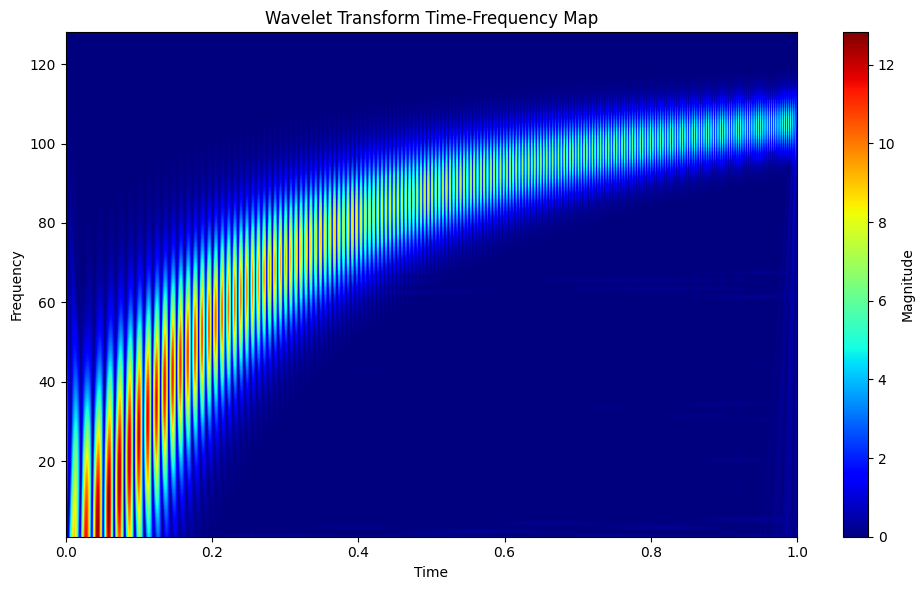

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pywt

duration = 5  # Duration of the signal in seconds
sample_rate = 1000  # Sampling rate in Hz
t = np.linspace(0, duration, int(duration * sample_rate), endpoint=False)

# Define the frequency transition
start_freq = 5  # Starting frequency in Hz
end_freq = 20  # Ending frequency in Hz

# Create the chirp signal
signal = np.sin(2 * np.pi * np.linspace(start_freq, end_freq, len(t)) * t)


# Continuous Wavelet Transform (CWT)
scales = np.arange(1, 128)
wavelet = 'morl'  # Choose a wavelet (e.g., Morlet wavelet)
coefficients, frequencies = pywt.cwt(signal, scales, wavelet)

# Plotting the time-frequency map
plt.figure(figsize=(10, 6))
plt.imshow(np.abs(coefficients), extent=[0, 1, 1, 128], cmap='jet', aspect='auto')
plt.title('Wavelet Transform Time-Frequency Map')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.colorbar(label='Magnitude')

plt.tight_layout()
plt.show()


/tmp/ipykernel_31738/3026626516.py:18: DeprecationWarning: Importing gaussian from 'scipy.signal' is deprecated and will raise an error in SciPy 1.13.0. Please use 'scipy.signal.windows.gaussian' or the convenience function 'scipy.signal.get_window' instead.
  gaussian_window = gaussian(len(t), std=100)  # Gaussian window


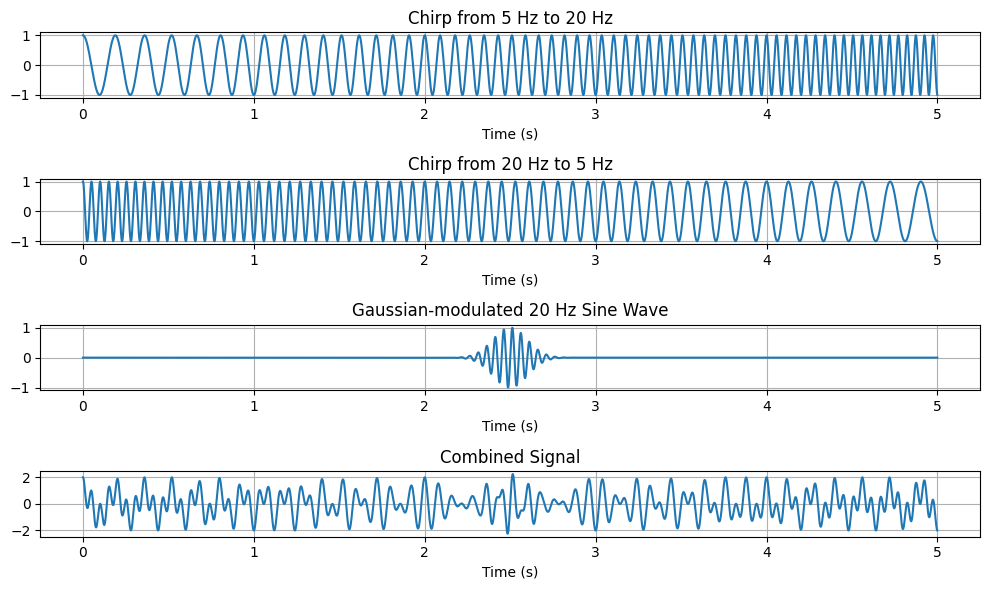

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import chirp, gaussian

# Define signal parameters
duration = 5  # Duration of the signal in seconds
sample_rate = 1000  # Sampling rate in Hz
t = np.linspace(0, duration, int(duration * sample_rate), endpoint=False)

# Creating the first chirp going from 5 Hz to 20 Hz
signal_chirp_1 = chirp(t, f0=5, f1=20, t1=duration, method='linear')

# Creating the second chirp going from 20 Hz to 5 Hz (reverse chirp)
signal_chirp_2 = chirp(t, f0=20, f1=5, t1=duration, method='linear')

# Creating a Gaussian-modulated 20 Hz sine wave peaking in the center
center = duration / 2  # Center of the signal
gaussian_window = gaussian(len(t), std=100)  # Gaussian window
sine_wave = np.sin(2 * np.pi * 20 * t)  # 20 Hz sine wave
signal_gaussian = gaussian_window * sine_wave

# Combine the signals
combined_signal = signal_chirp_1 + signal_chirp_2 + signal_gaussian

# Plotting the combined signal components
plt.figure(figsize=(10, 6))

plt.subplot(411)
plt.plot(t, signal_chirp_1)
plt.title('Chirp from 5 Hz to 20 Hz')
plt.xlabel('Time (s)')
plt.grid(True)

plt.subplot(412)
plt.plot(t, signal_chirp_2)
plt.title('Chirp from 20 Hz to 5 Hz')
plt.xlabel('Time (s)')
plt.grid(True)

plt.subplot(413)
plt.plot(t, signal_gaussian)
plt.title('Gaussian-modulated 20 Hz Sine Wave')
plt.xlabel('Time (s)')
plt.grid(True)

plt.subplot(414)
plt.plot(t, combined_signal)
plt.title('Combined Signal')
plt.xlabel('Time (s)')
plt.grid(True)

plt.tight_layout()
plt.show()


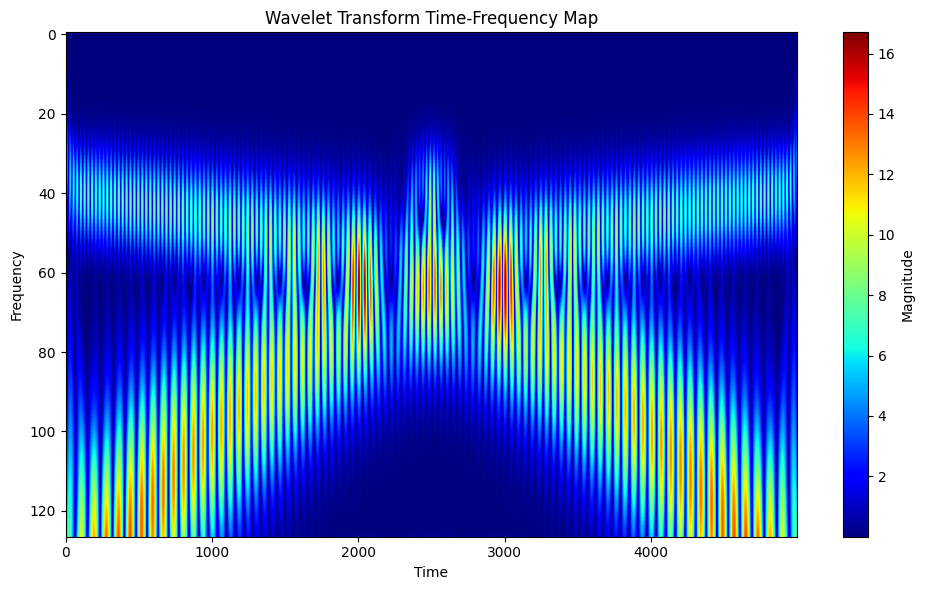

In [19]:
# Create the chirp signal
combined_signal = signal_chirp_1 + signal_chirp_2 + signal_gaussian

# Continuous Wavelet Transform (CWT)
scales = np.arange(1, 128)
wavelet = 'morl'  # Choose a wavelet (e.g., Morlet wavelet)
coefficients, frequencies = pywt.cwt(combined_signal, scales, wavelet)

# Plotting the time-frequency map
plt.figure(figsize=(10, 6))
plt.imshow(np.abs(coefficients), cmap='jet', aspect='auto')
plt.title('Wavelet Transform Time-Frequency Map')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.colorbar(label='Magnitude')

plt.tight_layout()
plt.show()
